In [1]:
from prophet import Prophet
import pandas as pd
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

df_t = pd.read_csv("../data/agg_transactions.csv")
df_t['state'] = df_t['state'].str.replace('-', ' ').str.title()
df_t['amount_cr'] = df_t['amount'] / 1e7

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
# create a proper date from year + quarter
def quarter_to_date(row):
    month = {1: '01', 2: '04', 3: '07', 4: '10'}[row['quarter']]
    return pd.to_datetime(f"{row['year']}-{month}-01")

df_t['ds'] = df_t.apply(quarter_to_date, axis=1)

# national level — total amount per quarter
national = df_t.groupby('ds')['amount_cr'].sum().reset_index()
national.columns = ['ds', 'y']
national = national.sort_values('ds')

print(f"Data points available: {len(national)}")
print(national.tail())

Data points available: 28
           ds             y
23 2023-10-01  2.704723e+06
24 2024-01-01  2.945843e+06
25 2024-04-01  3.182035e+06
26 2024-07-01  3.234697e+06
27 2024-10-01  3.599880e+06


In [3]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # quarterly data, no weekly pattern
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # growth compounds over time
    changepoint_prior_scale=0.3         # flexible trend changes
)

model.fit(national)
print("Model trained ✅")

14:01:29 - cmdstanpy - INFO - Chain [1] start processing
14:01:58 - cmdstanpy - INFO - Chain [1] done processing


Model trained ✅


In [4]:
# create future dates — 4 quarters ahead
future = model.make_future_dataframe(periods=4, freq='QS')
forecast = model.predict(future)

# show just the forecast part
future_only = forecast[forecast['ds'] > national['ds'].max()]
print("Forecast for next 4 quarters:")
print(future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].round(0))

Forecast for next 4 quarters:
           ds       yhat  yhat_lower  yhat_upper
28 2025-01-01  3720439.0   3705320.0   3739636.0
29 2025-04-01  4032966.0   3981262.0   4093966.0
30 2025-07-01  4068939.0   3965104.0   4174255.0
31 2025-10-01  4474159.0   4299013.0   4647968.0


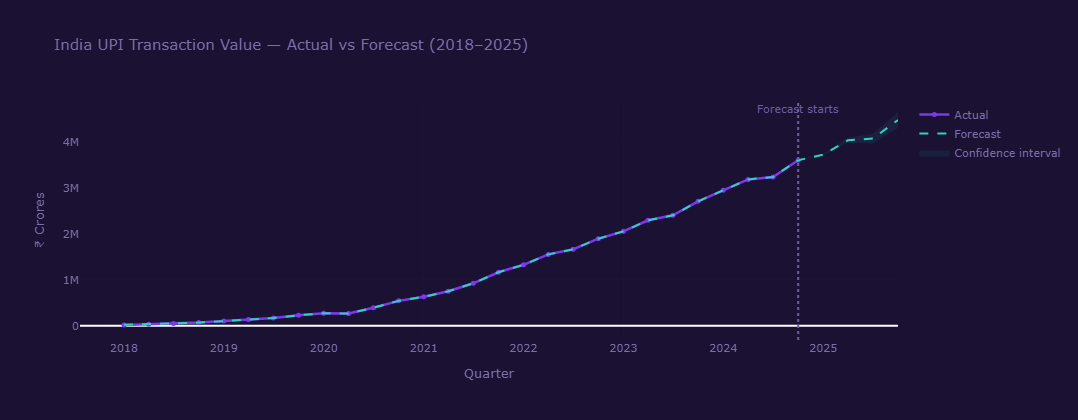

Chart saved ✅


In [5]:
import pandas as pd
import plotly.graph_objects as go

# Colors
PURPLE      = "#7c3aed"
PURPLE_LITE = "#a78bfa"
CARD_BG     = "#1a1133"
GRID_COL    = "#1e1535"
TEXT_SEC    = "#7b6fa8"

fig = go.Figure()

# actual data
fig.add_trace(go.Scatter(
    x=national['ds'], y=national['y'],
    mode='lines+markers',
    name='Actual',
    line=dict(color=PURPLE, width=2.5),
    marker=dict(size=5)
))

# forecast line
fig.add_trace(go.Scatter(
    x=forecast['ds'], y=forecast['yhat'],
    mode='lines',
    name='Forecast',
    line=dict(color='#2dd4bf', width=2, dash='dash')
))

# confidence band
fig.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself',
    fillcolor='rgba(45,212,191,0.08)',
    line=dict(color='rgba(0,0,0,0)'),
    name='Confidence interval'
))

# mark where forecast starts (using add_shape + add_annotation instead of add_vline)
split_date = national['ds'].max()

fig.add_shape(
    type="line",
    x0=split_date, x1=split_date,
    y0=0, y1=1,
    xref="x", yref="paper",
    line=dict(color="#6b5fa0", dash="dot")
)

fig.add_annotation(
    x=split_date,
    y=1,
    xref="x", yref="paper",
    text="Forecast starts",
    showarrow=False,
    font=dict(color="#6b5fa0")
)

# layout
fig.update_layout(
    title='India UPI Transaction Value — Actual vs Forecast (2018–2025)',
    paper_bgcolor=CARD_BG,
    plot_bgcolor=CARD_BG,
    font=dict(color=TEXT_SEC, size=11),
    xaxis=dict(gridcolor=GRID_COL, title='Quarter'),
    yaxis=dict(gridcolor=GRID_COL, title='₹ Crores'),
    legend=dict(bgcolor='rgba(0,0,0,0)'),
    height=420
)

# save and show
fig.write_html("../data/forecast_chart.html")
fig.show()
print("Chart saved ✅")


In [6]:
# forecast for Manipur specifically since it's your key insight
state_name = "Manipur"

state_df = df_t[df_t['state'] == state_name].groupby('ds')['amount_cr'].sum().reset_index()
state_df.columns = ['ds', 'y']
state_df = state_df.sort_values('ds')

m2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.3
)
m2.fit(state_df)

future2 = m2.make_future_dataframe(periods=4, freq='QS')
forecast2 = m2.predict(future2)

future_only2 = forecast2[forecast2['ds'] > state_df['ds'].max()]
print(f"\n{state_name} — Forecast next 4 quarters:")
print(future_only2[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].round(1).to_string(index=False))

14:02:11 - cmdstanpy - INFO - Chain [1] start processing
14:02:40 - cmdstanpy - INFO - Chain [1] done processing



Manipur — Forecast next 4 quarters:
        ds   yhat  yhat_lower  yhat_upper
2025-01-01 1251.0      1131.8      1369.4
2025-04-01 1476.9      1093.9      1928.3
2025-07-01 1401.0       727.0      2173.1
2025-10-01 1615.6       462.3      2892.6


In [7]:
forecast_export = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export.columns = ['date', 'predicted_amount_cr', 'lower_bound_cr', 'upper_bound_cr']
forecast_export['date'] = forecast_export['date'].dt.strftime('%Y-Q%q')
forecast_export['predicted_amount_cr'] = forecast_export['predicted_amount_cr'].round(0)
forecast_export.to_csv("../data/national_forecast.csv", index=False)
print("Forecast saved to /data/national_forecast.csv ✅")

Forecast saved to /data/national_forecast.csv ✅


In [11]:
import pandas as pd

# load forecast with correct column names
national_fc = pd.read_csv("../data/national_forecast.csv")
national_fc['ds'] = pd.to_datetime(national_fc['date'])
national_fc = national_fc.rename(columns={
    'predicted_amount_cr': 'yhat',
    'lower_bound_cr':      'yhat_lower',
    'upper_bound_cr':      'yhat_upper'
})

# reload actual data
df_t = pd.read_csv("../data/agg_transactions.csv")
df_t['state'] = df_t['state'].str.replace('-', ' ').str.title()
df_t['amount_cr'] = df_t['amount'] / 1e7

def quarter_to_date(row):
    month = {1:'01', 2:'04', 3:'07', 4:'10'}[row['quarter']]
    return pd.to_datetime(f"{row['year']}-{month}-01")

df_t['ds'] = df_t.apply(quarter_to_date, axis=1)

national = df_t.groupby('ds')['amount_cr'].sum().reset_index()
national.columns = ['ds', 'actual']

# merge actual + forecast
combined = pd.merge(
    national,
    national_fc[['ds','yhat','yhat_lower','yhat_upper']],
    on='ds', how='outer'
).sort_values('ds').reset_index(drop=True)

combined.to_csv("../data/forecast_combined.csv", index=False)
print("✅ forecast_combined.csv saved")
print(combined.tail(8))

✅ forecast_combined.csv saved
           ds        actual       yhat    yhat_lower    yhat_upper
24 2024-01-01  2.945843e+06  2945843.0  2.945843e+06  2.945843e+06
25 2024-04-01  3.182035e+06  3182035.0  3.182035e+06  3.182035e+06
26 2024-07-01  3.234697e+06  3234697.0  3.234697e+06  3.234697e+06
27 2024-10-01  3.599880e+06  3599880.0  3.599880e+06  3.599880e+06
28 2025-01-01           NaN  3720439.0  3.705320e+06  3.739636e+06
29 2025-04-01           NaN  4032966.0  3.981262e+06  4.093966e+06
30 2025-07-01           NaN  4068939.0  3.965104e+06  4.174255e+06
31 2025-10-01           NaN  4474159.0  4.299013e+06  4.647968e+06


In [1]:
import os
print(os.path.abspath("../data/forecast_combined.csv"))
print(os.path.exists("../data/forecast_combined.csv"))

c:\Users\Palash\Desktop\transfer file 2\Projects\phonepe-pulse-analysis\data\forecast_combined.csv
True


In [2]:
from prophet import Prophet
import pandas as pd

df_t = pd.read_csv("../data/agg_transactions.csv")
df_t['state'] = df_t['state'].str.replace('-', ' ').str.title()
df_t['amount_cr'] = df_t['amount'] / 1e7

def quarter_to_date(row):
    month = {1:'01', 2:'04', 3:'07', 4:'10'}[row['quarter']]
    return pd.to_datetime(f"{row['year']}-{month}-01")

df_t['ds'] = df_t.apply(quarter_to_date, axis=1)

state_df = df_t[df_t['state']=='Manipur'].groupby('ds')['amount_cr'].sum().reset_index()
state_df.columns = ['ds', 'y']
state_df = state_df.sort_values('ds').reset_index(drop=True)

m2 = Prophet(yearly_seasonality=True, weekly_seasonality=False,
             daily_seasonality=False, seasonality_mode='multiplicative',
             changepoint_prior_scale=0.3)
m2.fit(state_df)

future2   = m2.make_future_dataframe(periods=4, freq='QS')
forecast2 = m2.predict(future2)

forecast2[['ds','yhat','yhat_lower','yhat_upper']].round(1).to_csv(
    "../data/manipur_forecast.csv", index=False
)
print("✅ manipur_forecast.csv saved")

14:17:53 - cmdstanpy - INFO - Chain [1] start processing
14:18:24 - cmdstanpy - INFO - Chain [1] done processing


✅ manipur_forecast.csv saved


C:\Users\Palash\AppData\Local\Temp\ipykernel_32116\608491750.py:26: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  forecast2[['ds','yhat','yhat_lower','yhat_upper']].round(1).to_csv(
